# SupplyPrescript

## Notebook 1: Data Understanding and Initial Exploration

### Objective

The goal of this notebook is to understand the supply chain dataset before performing data preprocessing and machine learning.

This notebook covers:
- Loading the dataset
- Understanding the dataset structure
- Identifying missing values
- Detecting duplicates
- Exploring categorical and numerical features
- Understanding the target variable
- Documenting initial observations


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:


df = pd.read_csv(
    "C:/Users/USER/OneDrive/Desktop/VSCode/c++/SupplyPrescript/data/Raw/SupplyChain/DataCoSupplyChainDataset.csv",
    encoding="latin1"
)

In [4]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


### Observation

The dataset has multiple columns related to customers, products,
shipping information, sales, and delivery status.

In [5]:
print("Rows",df.shape[0])
print("Columnss",df.shape[1])

Rows 180519
Columnss 53


### Observation

Understanding the available columns helps identify
which features will be useful for prediction and optimization.

In [6]:
df.columns.tolist()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Email',
 'Customer Fname',
 'Customer Id',
 'Customer Lname',
 'Customer Password',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Order Zipcode',
 'Product Card Id',
 'Product Category Id',
 'Product Description',
 'Product Image',
 'Product Name',
 'Product P

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

In [7]:
df.describe(include='object')

C:\Users\USER\AppData\Local\Temp\ipykernel_3676\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Type,Delivery Status,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Lname,Customer Password,Customer Segment,...,Order City,Order Country,order date (DateOrders),Order Region,Order State,Order Status,Product Image,Product Name,shipping date (DateOrders),Shipping Mode
count,180519,180519,180519,180519,180519,180519,180519,180511,180519,180519,...,180519,180519,180519,180519,180519,180519,180519,180519,180519,180519
unique,4,4,50,563,2,1,782,1109,1,3,...,3597,164,65752,23,1089,9,118,118,63701,4
top,DEBIT,Late delivery,Cleats,Caguas,EE. UU.,XXXXXXXXX,Mary,Smith,XXXXXXXXX,Consumer,...,Santo Domingo,Estados Unidos,10/25/2016 14:39,Central America,Inglaterra,COMPLETE,http://images.acmesports.sports/Perfect+Fitnes...,Perfect Fitness Perfect Rip Deck,5/9/2015 18:02,Standard Class
freq,69295,98977,24551,66770,111146,180519,65150,64104,180519,93504,...,2211,24840,5,28341,6722,59491,24515,24515,10,107752


In [9]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(ascending=False)

Product Description    180519
Order Zipcode          155679
Customer Lname              8
Customer Zipcode            3
dtype: int64

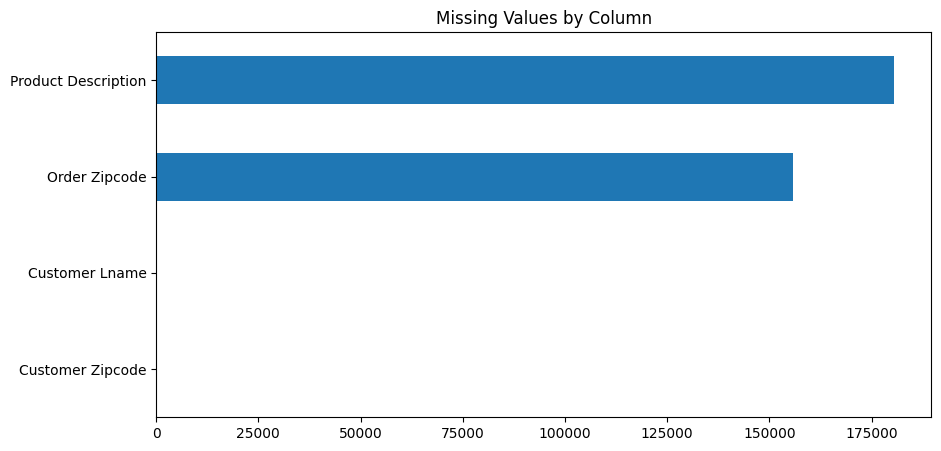

In [10]:
plt.figure(figsize=(10,5))

missing.sort_values().plot(kind='barh')

plt.title("Missing Values by Column")
plt.show()

### Observation

Identify which columns require cleaning before model training.

In [11]:
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [30]:
numerical = df.select_dtypes(include=np.number)
numerical.columns
numerical.columns.value_counts().sum()

np.int64(29)

In [31]:
categorical = df.select_dtypes(include='object')

categorical.columns

categorical.columns.value_counts().sum()

C:\Users\USER\AppData\Local\Temp\ipykernel_3676\1637572381.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = df.select_dtypes(include='object')


np.int64(24)

In [14]:
for col in categorical.columns:
    print(col)
    print(df[col].nunique())
    print("-"*40)

Type
4
----------------------------------------
Delivery Status
4
----------------------------------------
Category Name
50
----------------------------------------
Customer City
563
----------------------------------------
Customer Country
2
----------------------------------------
Customer Email
1
----------------------------------------
Customer Fname
782
----------------------------------------
Customer Lname
1109
----------------------------------------
Customer Password
1
----------------------------------------
Customer Segment
3
----------------------------------------
Customer State
46
----------------------------------------
Customer Street
7458
----------------------------------------
Department Name
11
----------------------------------------
Market
5
----------------------------------------
Order City
3597
----------------------------------------
Order Country
164
----------------------------------------
order date (DateOrders)
65752
---------------------------------------

In [15]:
df["Late_delivery_risk"].value_counts()

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

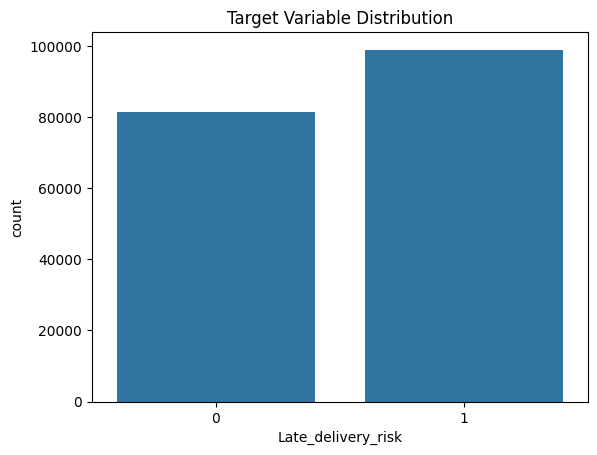

In [16]:
sns.countplot(x="Late_delivery_risk", data=df)

plt.title("Target Variable Distribution")
plt.show()

In [17]:
df["Shipping Mode"].value_counts()

Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

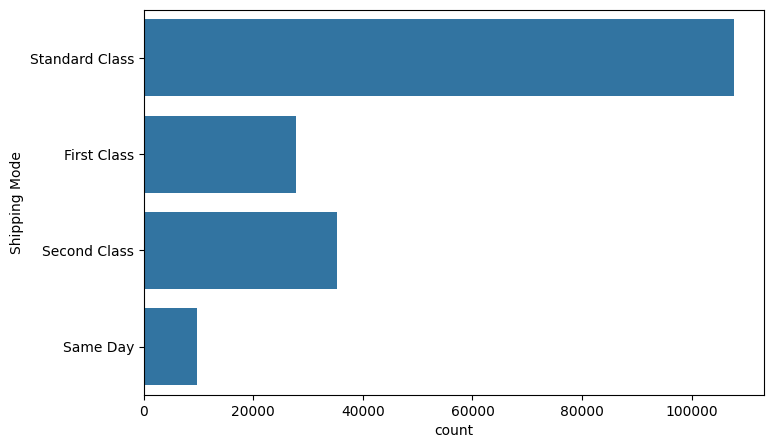

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(y="Shipping Mode", data=df)

plt.show()

In [19]:
df["Order Region"].value_counts().head(10)

Order Region
Central America    28341
Western Europe     27109
South America      14935
Oceania            10148
Northern Europe     9792
Southeast Asia      9539
Southern Europe     9431
Caribbean           8318
West of USA         7993
South Asia          7731
Name: count, dtype: int64

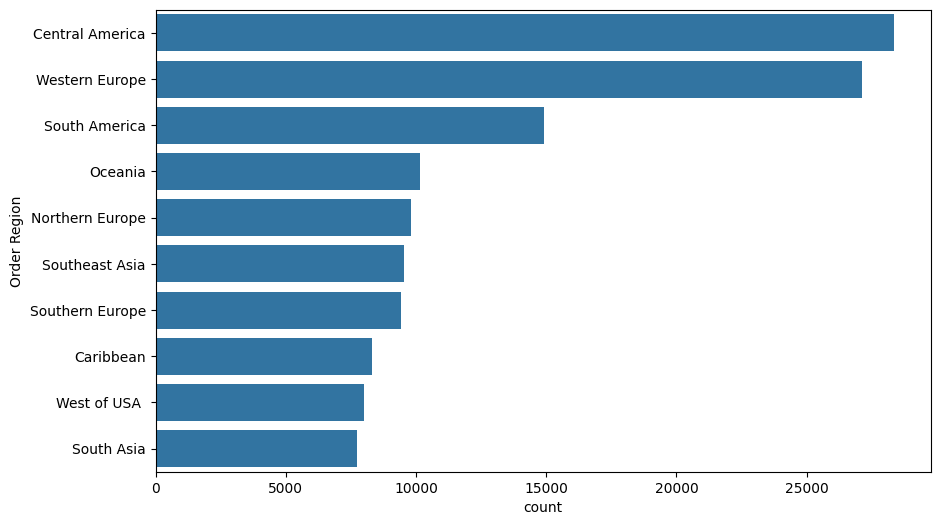

In [20]:
plt.figure(figsize=(10,6))

sns.countplot(y="Order Region",
              data=df,
              order=df["Order Region"].value_counts().index[:10])

plt.show()

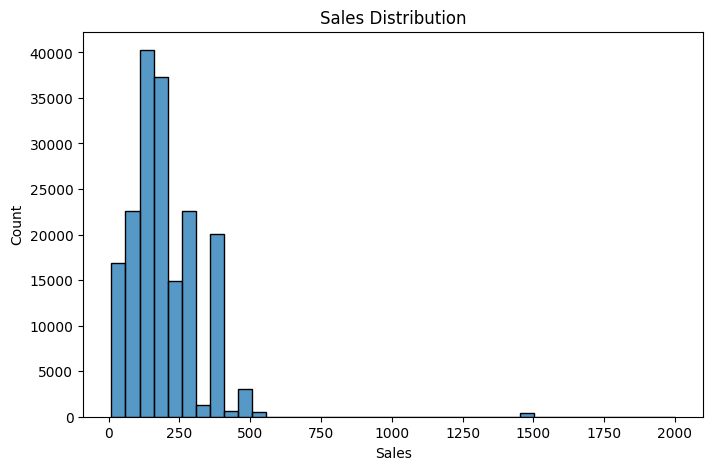

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(df["Sales"], bins=40)

plt.title("Sales Distribution")

plt.show()

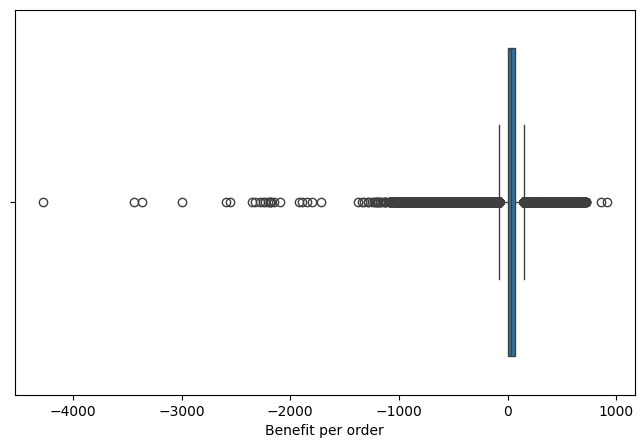

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Benefit per order"])

plt.show()

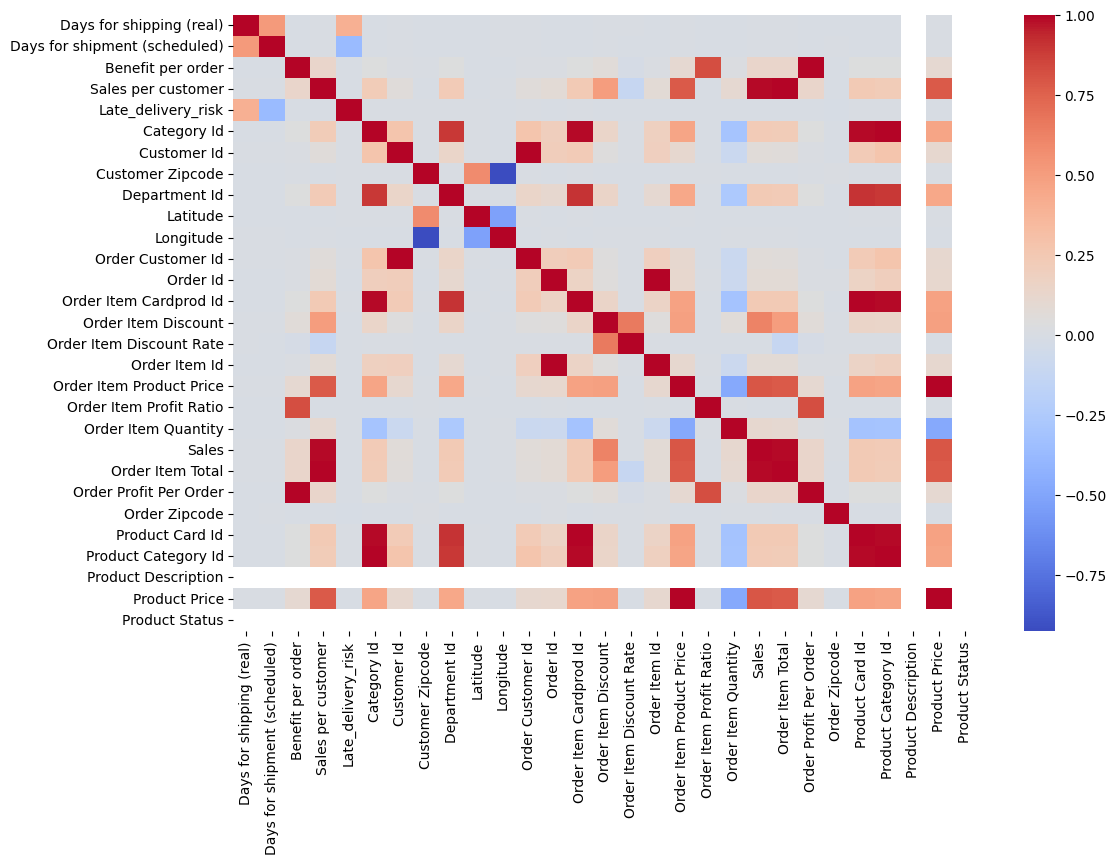

In [23]:
plt.figure(figsize=(12,8))

sns.heatmap(
    numerical.corr(),
    annot=False,
    cmap="coolwarm"
)

plt.show()

In [25]:
df["Shipping Mode"].value_counts()


Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

In [26]:
df.groupby("Order Region")["Sales"].sum().sort_values(ascending=False).head(10)


Order Region
Western Europe     5.894381e+06
Central America    5.665712e+06
South America      2.960881e+06
Northern Europe    2.155831e+06
Southern Europe    2.047919e+06
Oceania            2.016654e+06
Southeast Asia     1.932496e+06
Caribbean          1.651019e+06
West of USA        1.571416e+06
South Asia         1.553681e+06
Name: Sales, dtype: float64

In [27]:
df.groupby("Category Name")["Benefit per order"].mean().sort_values(ascending=False)


Category Name
Computers               157.594593
Garden                   69.097128
Crafts                   52.750351
Cameras                  51.165203
Fishing                  43.649106
Children's Clothing      41.684202
Sporting Goods           35.066135
Music                    33.263410
Camping & Hiking         31.135230
Consumer Electronics     30.680742
Cardio Equipment         30.672788
Golf Bags & Carts        29.673279
Women's Clothing         29.389000
Soccer                   28.275000
Women's Golf Clubs       27.782541
Basketball               27.547313
Health and Beauty        26.225497
Golf Shoes               23.675706
Kids' Golf Clubs         23.556875
Water Sports             20.923228
Boxing & MMA             20.428771
Baseball & Softball      20.193244
Cleats                   20.147323
Men's Golf Clubs         19.498198
Tennis & Racquet         17.524329
Fitness Accessories      17.017443
Women's Apparel          16.658951
Indoor/Outdoor Games     16.501784
Girls'

In [28]:
df.groupby("Department Name")["Sales"].sum().sort_values(ascending=False)

Department Name
Fan Shop              1.711387e+07
Apparel               7.976255e+06
Golf                  4.609028e+06
Footwear              4.006499e+06
Outdoors              1.253351e+06
Technology            1.039599e+06
Fitness               3.970509e+05
Discs Shop            2.288877e+05
Health and Beauty     1.060805e+05
Pet Shop              4.152480e+04
Book Shop             1.258740e+04
Name: Sales, dtype: float64

## Initial Findings

- Dataset contains approximately 180519 records.
- There are 29 numerical features.
- There are 24 categorical features.
- Missing values are concentrated in Product Description and Order Zipcode.
- Duplicate records: 0.
- Most orders are shipped using Standard class.
- The target variable appears balanced.
- Sales are concentrated in Western European regions.
